In [1]:
import pandas as pd
import yfinance as yf

raw = yf.download("PETR4.SA", start="2015-01-01", auto_adjust=True, progress=False) #usamos o auto_adjust=True pq o ajustado desconta dividendos, se usássemos False os valores de Close seriam diferentes
raw2 = yf.download("PETR4.SA", start="2015-01-01", auto_adjust=False, progress=False)

raw.head()

Price,Close,High,Low,Open,Volume
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA
Date,,,,,
2015-01-02,2.344783,2.502605,2.342278,2.502605,49559500
2015-01-05,2.144375,2.302197,2.136859,2.289671,78385100
2015-01-06,2.074232,2.212013,2.014109,2.181952,84723300
2015-01-07,2.171931,2.186962,2.094272,2.144375,85531000
2015-01-08,2.312217,2.352298,2.189466,2.201992,83306300


In [2]:
print(f"Primeiro dia da tabela: {raw.index.min()}")
print(f"Último dia da tabela: {raw.index.max()}")
print(f"Linhas da tabela: {len(pd.bdate_range(raw.index.min(), raw.index.max()))}")

Primeiro dia da tabela: 2015-01-02 00:00:00
Último dia da tabela: 2026-09-14 00:00:00
Linhas da tabela: 3052


<Axes: title={'center': 'PETR4 sem ajuste'}, xlabel='Date'>

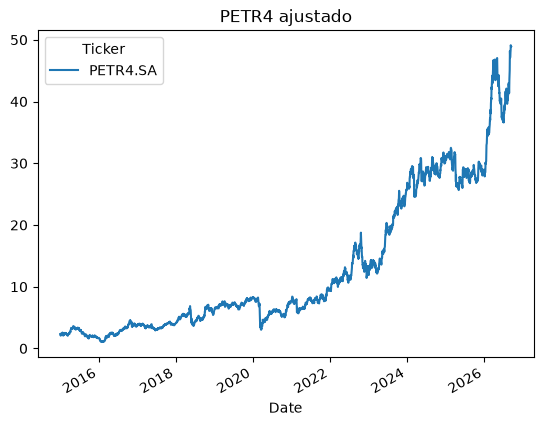

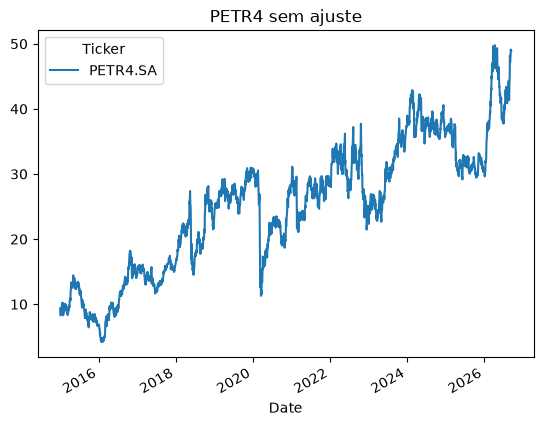

In [3]:
raw["Close"].plot(title="PETR4 ajustado")
raw2["Close"].plot(title="PETR4 sem ajuste")

In [4]:
TICKERS = ["PETR4","PETR3","VALE3","ITUB4","BBDC4","BBAS3","ABEV3","WEGE3",
           "B3SA3","RENT3","SUZB3","ELET3","PRIO3","RADL3","EQTL3","BPAC11",
           "ITSA4","LREN3","HAPV3","GGBR4","JBSS3","RAIL3","VIVT3","CSAN3",
           "EMBR3","TOTS3","CMIG4","BBSE3","ENEV3","SBSP3"]

raw = yf.download([t + ".SA" for t in TICKERS], start="2012-01-01", auto_adjust=True, progress=False)

prices = raw["Close"].copy()
prices.columns = [c.replace(".SA", "") for c in prices.columns]
prices.index = pd.DatetimeIndex(prices.index).tz_localize(None)
prices.shape

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: EMBR3.SA"}}}
$ELET3.SA: possibly delisted; no timezone found
$EMBR3.SA: possibly delisted; no timezone found
$JBSS3.SA: possibly delisted; no timezone found

3 Failed downloads:
['ELET3.SA', 'EMBR3.SA', 'JBSS3.SA']: possibly delisted; no timezone found


(3653, 30)

In [5]:
prices.isna().mean().sort_values(ascending=False).head(10) # Fração de NaN por ativo

ELET3     1.000000
EMBR3     1.000000
JBSS3     1.000000
HAPV3     0.429510
BPAC11    0.348754
RAIL3     0.219819
BBSE3     0.088694
BBDC4     0.000000
BBAS3     0.000000
CSAN3     0.000000
dtype: float64

<Axes: title={'center': 'Quantos ativos sem preço, por dia'}, xlabel='Date'>

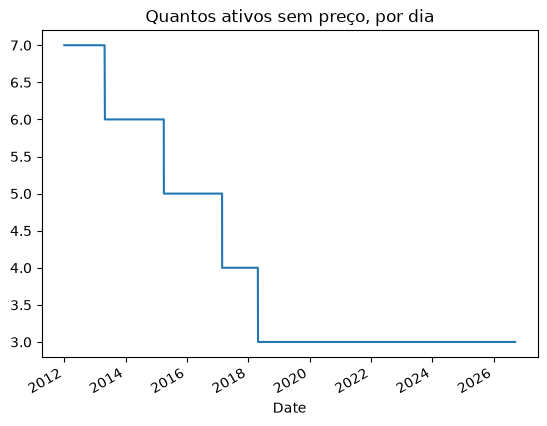

In [6]:
prices.isna().sum(axis=1).plot(title="Quantos ativos sem preço, por dia")

In [7]:
(prices.pct_change().abs() > 0.5).sum() # quantos dias com um retorno diário maior que 50% . Um retorno diário de 50% em ação é quase sempre um desdobramento mal ajustado

ABEV3     0
B3SA3     0
BBAS3     0
BBDC4     0
BBSE3     0
BPAC11    0
CMIG4     0
CSAN3     0
ELET3     0
EMBR3     0
ENEV3     0
EQTL3     0
GGBR4     0
HAPV3     0
ITSA4     0
ITUB4     0
JBSS3     0
LREN3     0
PETR3     0
PETR4     0
PRIO3     1
RADL3     0
RAIL3     0
RENT3     0
SBSP3     0
SUZB3     0
TOTS3     0
VALE3     0
VIVT3     0
WEGE3     0
dtype: int64

In [8]:
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = RAIZ / "data" / "raw"
RAW.mkdir(parents=True, exist_ok=True)

prices.to_parquet(RAW / "precos_brutos.parquet")

In [9]:
%load_ext autoreload
%autoreload 2

import logging
import sys
from pathlib import Path

import pandas as pd
from bcb import sgs

# o cwd do notebook é notebooks/, então todo caminho precisa sair da raiz do projeto
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = RAIZ / "data" / "raw"
sys.path.insert(0, str(RAIZ / "src"))

from moq import data

# sem isso os log.warning de dentro do moq não aparecem formatados
logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s", force=True)

print("raiz:", RAIZ)

raiz: /home/marialuisa/finance/mini-open-quant


In [10]:
prices = pd.read_parquet(RAW / "precos_brutos.parquet")
data.validate_prices(prices)
print("validação passou:", prices.shape)

# índice invertido tem que ser rejeitado — try/except pra ver a mensagem sem matar a célula
try:
    data.validate_prices(prices.iloc[::-1])
except ValueError as e:
    print("✓ rejeitou como esperado:", e)
else:
    print("✗ passou e não devia")

prices_clean = data.clean_prices(prices)
print("depois da limpeza:", prices_clean.shape)
print("NaN restante:", int(prices_clean.isna().sum().sum()))

WARNING moq.data: ativo BBSE3 removido: 8.9% ausente
WARNING moq.data: ativo BPAC11 removido: 34.9% ausente
WARNING moq.data: ativo ELET3 removido: 100.0% ausente
WARNING moq.data: ativo EMBR3 removido: 100.0% ausente
WARNING moq.data: ativo HAPV3 removido: 43.0% ausente
WARNING moq.data: ativo JBSS3 removido: 100.0% ausente
WARNING moq.data: ativo RAIL3 removido: 22.0% ausente


validação passou: (3653, 30)
✓ rejeitou como esperado: índice de datas fora de ordem
depois da limpeza: (3653, 23)
NaN restante: 0


In [11]:
# BBSE3 só abriu capital em 2013-04-29: antes disso não é dado faltando, é ação que não existia
t, d = "BBSE3", "2013-04-29"
janela = slice(pd.Timestamp(d) - pd.Timedelta(days=10), pd.Timestamp(d) + pd.Timedelta(days=10))
print(prices[t].loc[janela])

print(f"\n{t} sobreviveu à limpeza?", t in prices_clean.columns)

Date
2013-04-19         NaN
2013-04-22         NaN
2013-04-23         NaN
2013-04-24         NaN
2013-04-25         NaN
2013-04-26         NaN
2013-04-29    5.772943
2013-04-30    5.929438
2013-05-02    6.085933
2013-05-03    6.172876
2013-05-06    6.235474
2013-05-07    6.221563
2013-05-08    6.085933
2013-05-09    6.172876
Name: BBSE3, dtype: float64

BBSE3 sobreviveu à limpeza? False


In [ ]:
# o SGS só aceita janelas de até 10 anos em série diária: fetch_cdi baixa em blocos e concatena
cdi = data.fetch_cdi("2012-01-01")
print(cdi.head())
print("período:", cdi.index.min().date(), "→", cdi.index.max().date(), "| dias:", len(cdi))

ano = cdi["2023"]
acumulado = (1 + ano).prod() - 1
print(f"\nCDI acumulado em 2023: {acumulado:.2%}")

In [ ]:
cdi_al = data.align_cdi(cdi, prices_clean)
print("mesmo calendário dos preços:", cdi_al.index.equals(prices_clean.index))
print("NaN restante:", int(cdi_al.isna().sum()))

# a série em % ao dia (como vem do SGS) tem que ser barrada
try:
    data.align_cdi(cdi * 100, prices_clean)
except ValueError as e:
    print("✓ rejeitou como esperado:", e)
else:
    print("✗ passou e não devia")